# 📌 Descrição do Código — Regressão Linear

Este código utiliza o algoritmo de Regressão Linear, um método de Aprendizado Supervisionado aplicado a problemas de regressão, com o objetivo de analisar a relação entre os gastos em publicidade e o valor de vendas.

Modelo para TV
Coeficiente: 1.92
Intercepto: 174.14
------------------------------
Modelo para Rádio
Coeficiente: 4.79
Intercepto: 181.08
------------------------------
Modelo para Jornal
Coeficiente: 9.69
Intercepto: -235.94
------------------------------


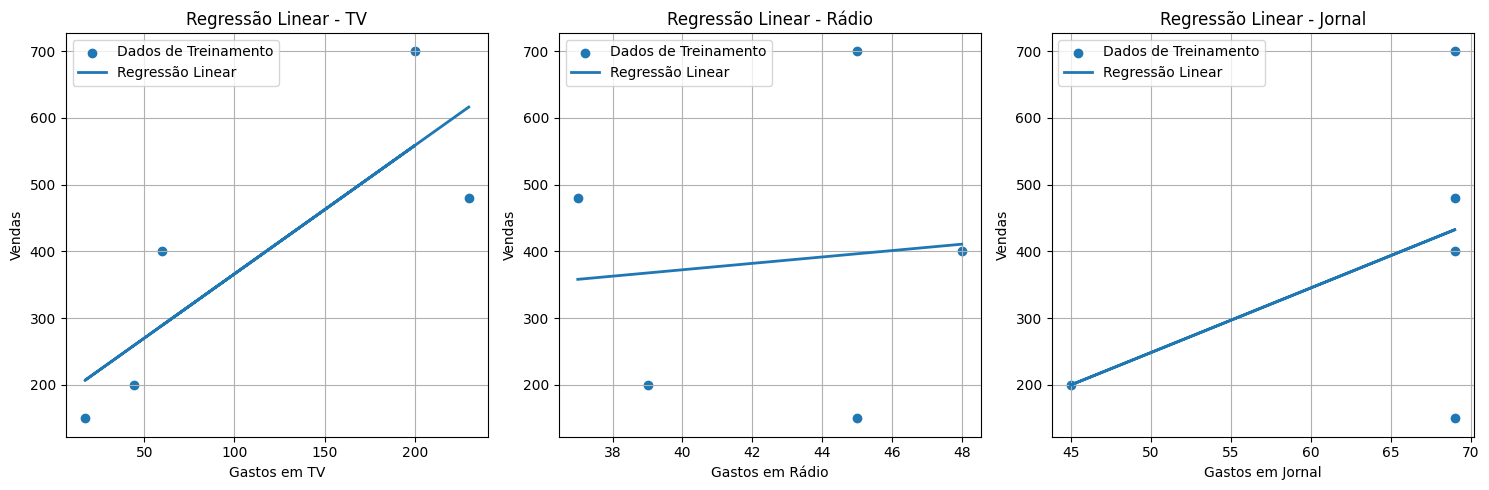

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dados de exemplo
gastos_tv = np.array([230, 44, 17, 200, 60]).reshape(-1, 1)
gastos_radio = np.array([37, 39, 45, 45, 48]).reshape(-1, 1)
gastos_jornal = np.array([69, 45, 69, 69, 69]).reshape(-1, 1)
vendas = np.array([480, 200, 150, 700, 400])

# Lista de dados de gastos
dados_gastos = [
    ("TV", gastos_tv),
    ("Rádio", gastos_radio),
    ("Jornal", gastos_jornal)
]

# Criar o modelo de regressão linear
modelo_regressao = LinearRegression()

# Criar subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Iterar sobre os dados de gastos
for i, (tipo_gasto, gastos) in enumerate(dados_gastos):

    # Ajustar o modelo aos dados
    modelo_regressao.fit(gastos, vendas)

    # Coeficientes do modelo
    coeficiente = modelo_regressao.coef_[0]
    intercepto = modelo_regressao.intercept_

    print(f"Modelo para {tipo_gasto}")
    print(f"Coeficiente: {coeficiente:.2f}")
    print(f"Intercepto: {intercepto:.2f}")
    print("-" * 30)

    # Plotar os dados e a linha de regressão
    axs[i].scatter(gastos, vendas, label="Dados de Treinamento")
    axs[i].plot(gastos, modelo_regressao.predict(gastos), linewidth=2, label="Regressão Linear")
    axs[i].set_title(f"Regressão Linear - {tipo_gasto}")
    axs[i].set_xlabel(f"Gastos em {tipo_gasto}")
    axs[i].set_ylabel("Vendas")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


# 📝 Descrição do Código — Árvore de Decisão

Este código utiliza o algoritmo de Árvore de Decisão, um modelo de Aprendizado Supervisionado aplicado a problemas de classificação. O objetivo é classificar frutas como Laranja ou Maçã com base em duas características: cor e textura.

Acurácia do modelo: 0.50


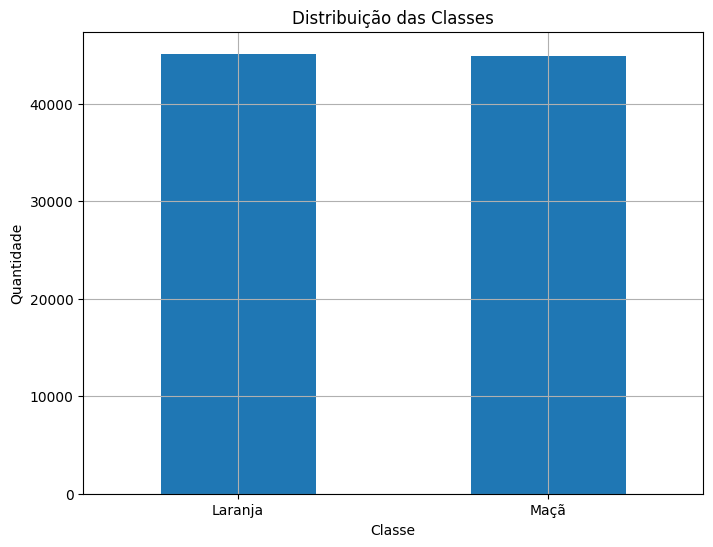

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Gerar dados de exemplo
np.random.seed(42)  # Para reprodutibilidade
cores = np.random.choice(['Laranja', 'Vermelha'], size=90000)
texturas = np.random.choice(['Rugosa', 'Lisa'], size=90000)
frutas = np.random.choice(['Laranja', 'Maçã'], size=90000)

# Criar DataFrame
df = pd.DataFrame({
    'Cor': cores,
    'Textura': texturas,
    'Fruta': frutas
})

# Mapear dados categóricos para numéricos
df['Cor'] = df['Cor'].map({'Laranja': 0, 'Vermelha': 1})
df['Textura'] = df['Textura'].map({'Rugosa': 0, 'Lisa': 1})
df['Fruta'] = df['Fruta'].map({'Laranja': 0, 'Maçã': 1})

# Separar features e target
X = df[['Cor', 'Textura']]
y = df['Fruta']

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Criar e treinar o modelo de Árvore de Decisão
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

# Fazer previsões
previsoes = modelo.predict(X_test)

# Calcular a acurácia
acuracia = accuracy_score(y_test, previsoes)
print(f"Acurácia do modelo: {acuracia:.2f}")

# Contagem de amostras de cada classe
contagem_classes = df['Fruta'].value_counts()

# Gráfico de barras
plt.figure(figsize=(8, 6))
contagem_classes.plot(kind='bar')
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Laranja', 'Maçã'], rotation=0)
plt.grid(True)
plt.show()

# 📝 Descrição do Código — Random Forest

Este código utiliza o algoritmo Random Forest, um método de Aprendizado Supervisionado aplicado a problemas de classificação. O objetivo é classificar flores do conjunto de dados Iris em três espécies diferentes, com base em suas características.

Precisão do modelo Random Forest: 1.0


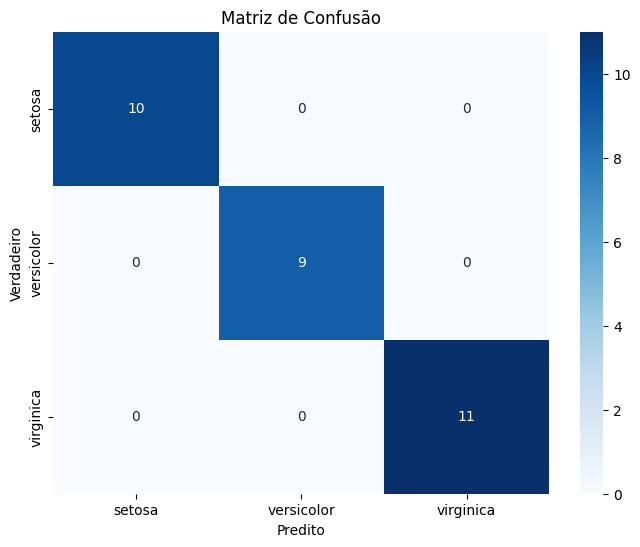

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Carregando o conjunto de dados Iris
iris = load_iris()
X = iris.data      # características
y = iris.target    # rótulos

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Criando e treinando o modelo Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred = rf_classifier.predict(X_test)

# Avaliando a precisão do modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisão do modelo Random Forest:", accuracy)

# Calculando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    cmap='Blues',
    fmt='g',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()


# 📝 Descrição do Código — Support Vector Machine (SVM)

Este código utiliza o algoritmo Support Vector Machine (SVM), um método de Aprendizado Supervisionado aplicado a problemas de classificação. O objetivo é separar dois grupos de dados utilizando um hiperplano de separação.

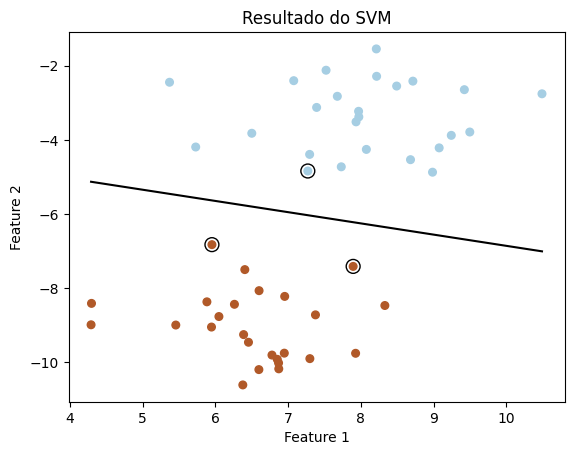

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

# Gerando um conjunto de dados sintético para classificação binária
X, y = make_blobs(n_samples=50, centers=2, random_state=6)

# Criando o classificador SVM com kernel linear
clf = svm.SVC(kernel='linear')

# Treinando o modelo SVM
clf.fit(X, y)

# Plotando os pontos de dados
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# Obtendo os coeficientes do hiperplano
w = clf.coef_[0]
b = clf.intercept_[0]

# Gerando os valores para a linha de separação
x_plot = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)
y_plot = -(w[0] * x_plot + b) / w[1]

# Plotando a linha de separação
plt.plot(x_plot, y_plot, 'k-')

# Plotando os vetores de suporte
plt.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors='none',
    edgecolors='k'
)

plt.title('Resultado do SVM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


# 📝 Descrição do Código — k-Nearest Neighbors (k-NN)

Este código utiliza o algoritmo k-Nearest Neighbors (k-NN), um método de Aprendizado Supervisionado aplicado a problemas de classificação. O objetivo é classificar flores do conjunto de dados Iris com base em suas características.

Acurácia do modelo KNN: 0.8


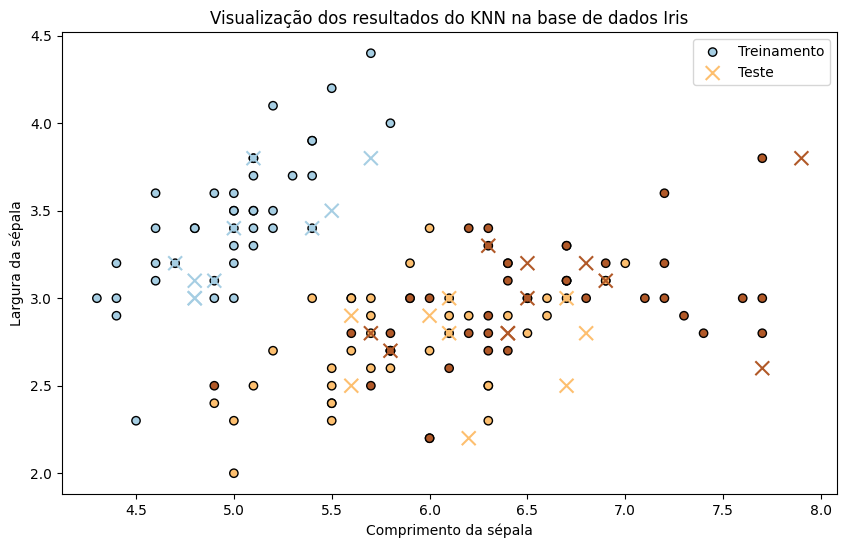

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Carregar o conjunto de dados Iris
iris = datasets.load_iris()

# Utilizar apenas as duas primeiras características para facilitar a visualização
X = iris.data[:, :2]
y = iris.target

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Inicializar o classificador k-NN
k = 5  # número de vizinhos
knn = KNeighborsClassifier(n_neighbors=k)

# Treinar o classificador k-NN
knn.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = knn.predict(X_test)

# Calcular a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia do modelo KNN:", accuracy)

# Plotar os resultados
plt.figure(figsize=(10, 6))

# Pontos de treinamento
plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c=y_train, cmap=plt.cm.Paired,
    label='Treinamento', edgecolors='k'
)

# Pontos de teste
plt.scatter(
    X_test[:, 0], X_test[:, 1],
    c=y_pred, cmap=plt.cm.Paired,
    label='Teste', marker='x', s=100
)

plt.legend()
plt.xlabel('Comprimento da sépala')
plt.ylabel('Largura da sépala')
plt.title('Visualização dos resultados do KNN na base de dados Iris')
plt.show()


# 📝 Descrição do Código — Naive Bayes

Este código utiliza o algoritmo Naive Bayes Gaussiano, um método de Aprendizado Supervisionado aplicado a problemas de classificação. O objetivo é classificar flores do conjunto de dados Iris em diferentes espécies com base em suas características.

Acurácia do modelo: 1.0


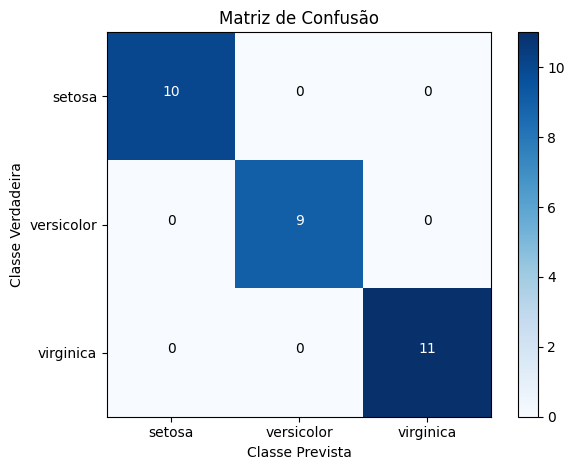

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Carregando o conjunto de dados Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividindo os dados em conjunto de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Criando e treinando o modelo Naive Bayes Gaussiano
model = GaussianNB()
model.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred = model.predict(X_test)

# Calculando a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia do modelo:", accuracy)

# Calculando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.colorbar()

classes = iris.target_names
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Inserindo os valores dentro da matriz
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i, conf_matrix[i, j],
            horizontalalignment="center",
            color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black"
        )

plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.show()


# Interpretação dos Resultados — Regressão Linear

**Tipo de problema:** Regressão  

O modelo de Regressão Linear foi aplicado para analisar a relação entre os gastos em publicidade e o valor de vendas, caracterizando um problema de regressão, pois o objetivo é prever valores numéricos contínuos.

Os resultados indicam que o modelo conseguiu ajustar uma relação linear entre as variáveis analisadas. Os coeficientes representam o impacto médio de cada tipo de gasto sobre as vendas, enquanto o intercepto indica o valor estimado de vendas quando não há investimento.

Uma limitação observada é o pequeno número de amostras, o que reduz a capacidade de generalização do modelo. Além disso, a regressão linear assume uma relação estritamente linear, o que pode não representar cenários reais mais complexos.

Em um contexto organizacional, esse modelo pode ser utilizado como uma análise inicial para apoiar decisões sobre investimentos em marketing.

# Interpretação dos Resultados — Árvore de Decisão

**Tipo de problema:** Classificação  

A Árvore de Decisão foi aplicada para classificar frutas com base em suas características. O valor de acurácia obtido indica um desempenho limitado do modelo, sugerindo dificuldade em identificar padrões relevantes nos dados.

Esse resultado é coerente com o conjunto de dados utilizado, que foi gerado de forma aleatória, sem uma relação clara entre as variáveis de entrada e a classe alvo. Dessa forma, o modelo não consegue aprender regras eficientes para a classificação.

Como limitação, a árvore de decisão é sensível à qualidade dos dados e pode gerar decisões pouco confiáveis quando não há padrões bem definidos.

Em aplicações reais, esse modelo pode ser útil em sistemas de apoio à decisão por sua facilidade de interpretação, desde que treinado com dados mais representativos.

# Interpretação dos Resultados — Random Forest

**Tipo de problema:** Classificação  

O modelo Random Forest apresentou alta acurácia, indicando excelente desempenho na classificação das espécies do conjunto de dados Iris.

A matriz de confusão mostra poucos ou nenhum erro de classificação, evidenciando a capacidade do modelo de generalizar bem os dados. Esse resultado é esperado, pois o Random Forest combina múltiplas árvores de decisão, tornando o modelo mais robusto.

Uma limitação do Random Forest é a menor interpretabilidade em comparação a modelos mais simples.

Em um contexto organizacional, esse modelo é amplamente utilizado em problemas como detecção de fraudes, análise de risco e classificação de clientes.

# Interpretação dos Resultados — Support Vector Machine (SVM)

**Tipo de problema:** Classificação  

O modelo SVM conseguiu separar adequadamente as classes por meio de um hiperplano de decisão, conforme observado no gráfico gerado.

Os vetores de suporte representam os pontos mais próximos da fronteira de decisão e são fundamentais para o funcionamento do algoritmo. O resultado indica que o modelo foi eficiente para o conjunto de dados utilizado.

Entre as limitações, destaca-se a sensibilidade à escolha do kernel e o custo computacional em bases de dados maiores.

Em aplicações reais, o SVM é utilizado em reconhecimento de padrões, classificação de textos e visão computacional.

# Interpretação dos Resultados — k-Nearest Neighbors (k-NN)

**Tipo de problema:** Classificação  

O algoritmo k-NN apresentou bom desempenho, com acurácia satisfatória. A classificação ocorre com base na proximidade entre as amostras de dados.

O resultado é coerente com o funcionamento do algoritmo, que atribui a classe mais frequente entre os vizinhos mais próximos para classificar novas amostras.

Como limitação, o k-NN possui alto custo computacional em grandes bases de dados e é sensível à escolha do valor de k e à escala das variáveis.

Em contextos organizacionais, esse modelo pode ser aplicado em sistemas de recomendação e análise baseada em similaridade.

# Interpretação dos Resultados — Naive Bayes

**Tipo de problema:** Classificação  

O modelo Naive Bayes Gaussiano apresentou alta acurácia, indicando bom desempenho na classificação das espécies do conjunto de dados Iris.

A matriz de confusão confirma que a maioria das amostras foi classificada corretamente. Esse resultado é coerente com a hipótese de independência entre as variáveis adotada pelo algoritmo.

A principal limitação do modelo é justamente essa suposição de independência, que nem sempre é válida em dados reais.

Em aplicações práticas, o Naive Bayes é amplamente utilizado em filtros de spam, classificação de textos e análise de sentimentos.


# Considerações Finais

Nesta atividade foram reproduzidos e analisados diferentes modelos de aprendizado supervisionado,
permitindo comparar seu comportamento em problemas de regressão e classificação.

Os resultados obtidos demonstram que modelos mais simples podem ser úteis em análises iniciais,
enquanto modelos mais robustos, como Random Forest e SVM, apresentam melhor desempenho em cenários
mais complexos.

Do ponto de vista organizacional, esses modelos podem apoiar a tomada de decisão, desde que utilizados
com dados representativos e com atenção a aspectos éticos, como uso responsável dos dados e
interpretação adequada dos resultados.
